In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, roc_auc_score, roc_curve
import joblib

In [2]:
df = pd.read_csv("/Users/alexkochu/Documents/nasa_neows_asteroids_3000.csv")

In [3]:
df.head()

,id,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous,close_approach_date,relative_velocity_kmps,miss_distance_km
0,2001620,1620 Geographos (1951 RA),15.26,2.358061,5.272784,True,1901-08-23,11.762812,5.071251e+06
1,2001863,1863 Antinous (1948 EA),15.46,2.150577,4.808836,False,1907-10-11,18.079514,1.337871e+07
2,2001915,1915 Quetzalcoatl (1953 EA),18.38,0.560473,1.253257,False,1906-03-06,15.120986,3.789658e+06
3,2001917,1917 Cuyo (1968 AA),14.38,3.536348,7.907514,False,1926-09-28,15.234490,1.687224e+07
4,2002063,2063 Bacchus (1977 HB),17.21,0.960627,2.148028,False,1903-03-06,10.389112,9.959875e+06


In [4]:
df.isnull().sum()

id                             0
name                           0
absolute_magnitude_h           0
estimated_diameter_min_km      0
estimated_diameter_max_km      0
is_potentially_hazardous       0
close_approach_date          229
relative_velocity_kmps       229
miss_distance_km             229
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         3200 non-null   int64  
 1   name                       3200 non-null   object 
 2   absolute_magnitude_h       3200 non-null   float64
 3   estimated_diameter_min_km  3200 non-null   float64
 4   estimated_diameter_max_km  3200 non-null   float64
 5   is_potentially_hazardous   3200 non-null   bool   
 6   close_approach_date        2971 non-null   object 
 7   relative_velocity_kmps     2971 non-null   float64
 8   miss_distance_km           2971 non-null   float64
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 203.3+ KB


In [6]:
df = df.drop(columns=["id", "close_approach_date"])

In [7]:
df.head()

,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous,relative_velocity_kmps,miss_distance_km
0,1620 Geographos (1951 RA),15.26,2.358061,5.272784,True,11.762812,5.071251e+06
1,1863 Antinous (1948 EA),15.46,2.150577,4.808836,False,18.079514,1.337871e+07
2,1915 Quetzalcoatl (1953 EA),18.38,0.560473,1.253257,False,15.120986,3.789658e+06
3,1917 Cuyo (1968 AA),14.38,3.536348,7.907514,False,15.234490,1.687224e+07
4,2063 Bacchus (1977 HB),17.21,0.960627,2.148028,False,10.389112,9.959875e+06


In [8]:
#select all the categoricals and booleans and assigning to cat col variable 
cat_col = df.select_dtypes(include=["object","bool"]).columns

In [9]:
#putting thee null columns to num_col and filling it with mean
num_col = df[["relative_velocity_kmps","miss_distance_km"]]
for col in num_col:
    df[col] = df[col].fillna(df[col].mean())

In [10]:
df.isnull().sum()

name                         0
absolute_magnitude_h         0
estimated_diameter_min_km    0
estimated_diameter_max_km    0
is_potentially_hazardous     0
relative_velocity_kmps       0
miss_distance_km             0
dtype: int64

/var/folders/9c/yc25ycx52hj55s68cdymw5140000gn/T/ipykernel_13915/3936694503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


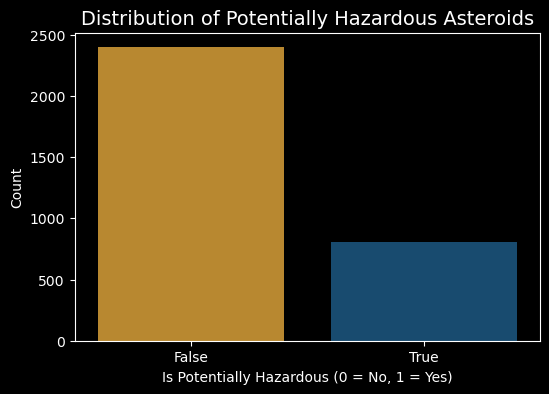

In [11]:
plt.style.use("dark_background")
plt.figure(figsize=(6,4))
sns.countplot(
    x="is_potentially_hazardous",
    data=df,
    palette=["#cf8f19", "#094d7e"]
)

plt.title("Distribution of Potentially Hazardous Asteroids", fontsize=14)
plt.xlabel("Is Potentially Hazardous (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


#Most asteroids are non-hazardous, but a small percentage are classified as potentially hazardous, which justifies the need for risk prediction.


/var/folders/9c/yc25ycx52hj55s68cdymw5140000gn/T/ipykernel_13915/3057683782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


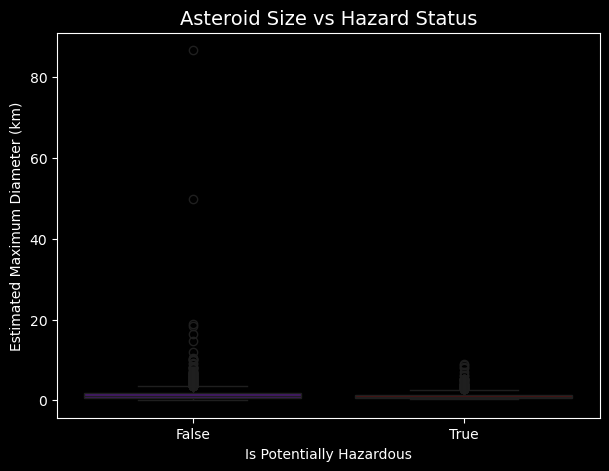

In [12]:
plt.style.use("dark_background")
plt.figure(figsize=(7,5))
sns.boxplot(
    x="is_potentially_hazardous",
    y="estimated_diameter_max_km",
    data=df,
    palette=["#470b7b", "#610505"]
)

plt.title("Asteroid Size vs Hazard Status", fontsize=14)
plt.xlabel("Is Potentially Hazardous")
plt.ylabel("Estimated Maximum Diameter (km)")
plt.show()


/var/folders/9c/yc25ycx52hj55s68cdymw5140000gn/T/ipykernel_13915/3047320422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


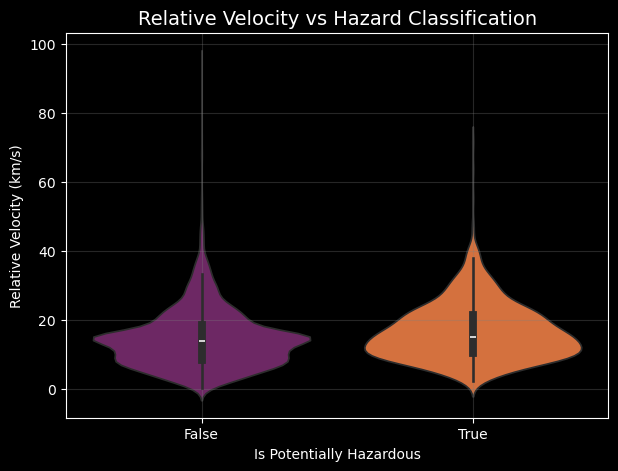

In [13]:
plt.style.use("dark_background")
plt.figure(figsize=(7,5))

sns.violinplot(
    x="is_potentially_hazardous",
    y="relative_velocity_kmps",
    data=df,
    palette="inferno"
)

plt.title("Relative Velocity vs Hazard Classification", fontsize=14)
plt.xlabel("Is Potentially Hazardous")
plt.ylabel("Relative Velocity (km/s)")

plt.grid(color="gray", alpha=0.3)
plt.show()


/var/folders/9c/yc25ycx52hj55s68cdymw5140000gn/T/ipykernel_13915/4270649648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


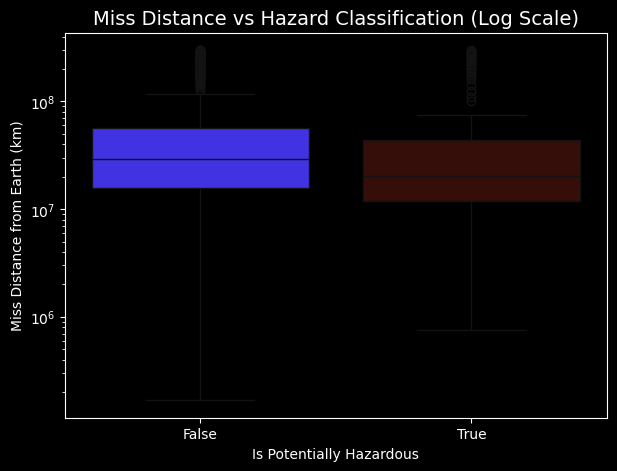

In [14]:
plt.style.use("dark_background")
plt.figure(figsize=(7,5))
sns.boxplot(
    x="is_potentially_hazardous",
    y="miss_distance_km",
    data=df,
    palette=["#2916ff", "#3c0802"]
)

plt.yscale("log")
plt.title("Miss Distance vs Hazard Classification (Log Scale)", fontsize=14)
plt.xlabel("Is Potentially Hazardous")
plt.ylabel("Miss Distance from Earth (km)")
plt.show()


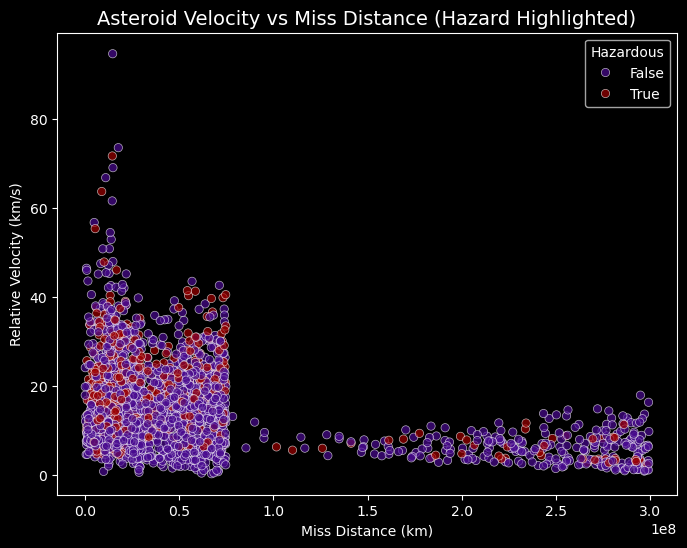

In [15]:
plt.style.use("dark_background")
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="miss_distance_km",
    y="relative_velocity_kmps",
    hue="is_potentially_hazardous",
    data=df,
    palette={0:"#490b909c", 1:"#9C0000"},
    alpha=0.7
)

plt.title("Asteroid Velocity vs Miss Distance (Hazard Highlighted)", fontsize=14)
plt.xlabel("Miss Distance (km)")
plt.ylabel("Relative Velocity (km/s)")
plt.legend(title="Hazardous")
plt.show()


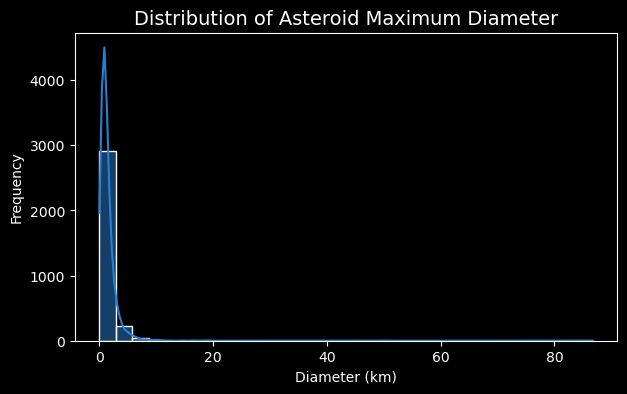

In [16]:
plt.style.use("dark_background")
plt.figure(figsize=(7,4))
sns.histplot(
    df["estimated_diameter_max_km"],
    bins=30,
    kde=True,
    color="#2b7fd3"
)

plt.title("Distribution of Asteroid Maximum Diameter", fontsize=14)
plt.xlabel("Diameter (km)")
plt.ylabel("Frequency")
plt.show()


In [17]:
lb = LabelEncoder()

df["is_potentially_hazardous"] = lb.fit_transform(df["is_potentially_hazardous"])
df["name"] = lb.fit_transform(df["name"])

In [18]:
df.head()

,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous,relative_velocity_kmps,miss_distance_km
0,575,15.26,2.358061,5.272784,1,11.762812,5.071251e+06
1,767,15.46,2.150577,4.808836,0,18.079514,1.337871e+07
2,801,18.38,0.560473,1.253257,0,15.120986,3.789658e+06
3,803,14.38,3.536348,7.907514,0,15.234490,1.687224e+07
4,848,17.21,0.960627,2.148028,0,10.389112,9.959875e+06


# SPLIT THE DATA

In [19]:
X = df.drop(columns=["is_potentially_hazardous", "name"],axis = 1)
y = df["is_potentially_hazardous"]

In [20]:
df.head()

,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous,relative_velocity_kmps,miss_distance_km
0,575,15.26,2.358061,5.272784,1,11.762812,5.071251e+06
1,767,15.46,2.150577,4.808836,0,18.079514,1.337871e+07
2,801,18.38,0.560473,1.253257,0,15.120986,3.789658e+06
3,803,14.38,3.536348,7.907514,0,15.234490,1.687224e+07
4,848,17.21,0.960627,2.148028,0,10.389112,9.959875e+06


In [21]:
sc = StandardScaler()
x_scaled = sc.fit_transform(X)

In [22]:
df.head()

,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous,relative_velocity_kmps,miss_distance_km
0,575,15.26,2.358061,5.272784,1,11.762812,5.071251e+06
1,767,15.46,2.150577,4.808836,0,18.079514,1.337871e+07
2,801,18.38,0.560473,1.253257,0,15.120986,3.789658e+06
3,803,14.38,3.536348,7.907514,0,15.234490,1.687224e+07
4,848,17.21,0.960627,2.148028,0,10.389112,9.959875e+06


In [23]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.2,random_state = 100)

In [24]:
model_LR = LogisticRegression()
model_LR.fit(X_train, y_train)

y_pred_LR = model_LR.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))
joblib.dump(model_LR, "logistic_model.pkl")

Logistic Regression Accuracy: 0.771875
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       495
           1       0.00      0.00      0.00       145

    accuracy                           0.77       640
   macro avg       0.39      0.50      0.44       640
weighted avg       0.60      0.77      0.67       640



['logistic_model.pkl']

In [25]:
model_RF = RandomForestClassifier(n_estimators=200,random_state=42)
model_RF.fit(X_train, y_train)

y_pred_RF = model_RF.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_RF))
print(classification_report(y_test, y_pred_RF))
joblib.dump(model_RF, "random_forest_model.pkl")

Random Forest Accuracy: 0.7359375
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       495
           1       0.37      0.23      0.29       145

    accuracy                           0.74       640
   macro avg       0.58      0.56      0.56       640
weighted avg       0.70      0.74      0.71       640



['random_forest_model.pkl']

In [26]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
joblib.dump(model_knn, "knn_model.pkl")


KNN Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       495
           1       0.32      0.29      0.30       145

    accuracy                           0.70       640
   macro avg       0.56      0.55      0.56       640
weighted avg       0.69      0.70      0.69       640



['knn_model.pkl']

In [27]:
model_svm = SVC(kernel="rbf", probability=True)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("SVM Accuracy:",accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
joblib.dump(model_svm, "svm_model.pkl")

joblib.dump(sc, "scaler.pkl")


SVM Accuracy: 0.7734375
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       495
           1       0.00      0.00      0.00       145

    accuracy                           0.77       640
   macro avg       0.39      0.50      0.44       640
weighted avg       0.60      0.77      0.67       640



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


['scaler.pkl']

In [28]:
np.sqrt(3000)

np.float64(54.772255750516614)

In [29]:
df.isnull().sum()

name                         0
absolute_magnitude_h         0
estimated_diameter_min_km    0
estimated_diameter_max_km    0
is_potentially_hazardous     0
relative_velocity_kmps       0
miss_distance_km             0
dtype: int64